<a href="https://colab.research.google.com/github/NaomiRios/Analitica-de-Negocios/blob/main/Proyecto_Final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CASO DE ESTUDIO**

**1. Introducción y Contexto del Negocio:**
En el sector del comercio minorista en línea (Online Retail), la retención de clientes se ha consolidado como el pilar fundamental para garantizar la rentabilidad y la sostenibilidad financiera a largo plazo. Las organizaciones enfrentan un entorno altamente competitivo donde los costos asociados a la adquisición de nuevos usuarios (marketing, publicidad, promociones de bienvenida) resultan elevados. La literatura comercial demuestra de manera consistente que retener a un cliente existente es hasta cinco veces más económico que adquirir uno nuevo.

Históricamente, las decisiones empresariales en torno a la pérdida de clientes se han ejecutado de manera reactiva, es decir, mediante la implementación de estrategias de recuperación cuando el usuario ya ha abandonado la plataforma. Este proyecto implementó un enfoque proactivo y guiado por datos (Data-Driven). Utilizando la analítica predictiva y modelos de Machine Learning en el lenguaje Python, la organización analizó los patrones de comportamiento y las señales tempranas de insatisfacción para anticiparse a la deserción del cliente.

**2. Objetivos del Proyecto**
Para resolver la problemática de negocio de manera integral, en este cuaderno de Google Colab se estructuró un enfoque analítico dual basado en los bloques algorítmicos estudiados en el ciclo académico:

- Clasificación Basada en Riesgo (Árbol de Decisión): Se automatizó la detección temprana de usuarios con alta probabilidad de fuga, lo que permitió al departamento de Marketing ejecutar campañas de fidelización y retención ultra-dirigidas de manera oportuna.

- Agrupamiento y Segmentación Comercial (K-Means Clustering): Se identificaron grupos homogéneos de clientes según sus patrones de consumo, fricción y comportamiento, con el fin de proporcionar a la alta gerencia las herramientas necesarias para personalizar la oferta de valor y optimizar los recursos operativos.

**3.Descripción Clara de las Variables:**
A continuación, se detallan las variables reales que conforman la base de datos analizada. Para dar cumplimiento estricto a los lineamientos del proyecto, estas se han clasificado según el rol estratégico que desempeñaron dentro de los modelos algorítmicos:

- Variables Objetivo (Variables a Predecir)
  - Abandono_Cliente (Variable de Clasificación): Variable categórica binaria (1 si el cliente dejó la tienda, 0 si continúa activo). Constituyó el eje central del modelo de clasificación para medir el riesgo de fuga.  
  - Gasto_Total (Variable de Pronóstico Comercial): Variable numérica continua que representa el monto total de dinero que el cliente gastó en el último año. Se utilizó como la variable objetivo para evaluar el valor económico del usuario.

- Variables Explicativas (Predictores/Características)
  - Customer_ID: Identificador único de cada cliente. Se excluyó del entrenamiento de los modelos por no aportar valor predictivo (actúa únicamente como etiqueta de registro).

  - Edad: Edad biológica del cliente, empleada para identificar tendencias de consumo por ciclo de vida.

  - Genero: Género con el que se identifica el usuario (Male, Female, Other).

  - Ingreso_Anual: El ingreso estimado del usuario al año (expresado en miles de dólares).

  - Años_como_Cliente: Antigüedad o tiempo total (en años) que el usuario lleva registrado como cliente en la plataforma.

  - Num_de_Compras: Cantidad de transacciones exitosas realizadas por el usuario en el último año.

  - Monto_Promedio_Transaccion: El valor promedio consumido por el cliente en cada transacción individual.

  - Num_Devoluciones: Cantidad de artículos devueltos por el cliente en el último año; funciona como un indicador directo de fallas en la experiencia de compra.

  - Num_contactos_soporte: Número de veces que el cliente contactó al canal de soporte o atención al cliente debido a incidencias o dudas. Mide el nivel de fricción en el servicio.

  - Puntuacion_Satisfaccion: Calificación ordinal del 1 al 5 que el cliente otorgó a la tienda según su experiencia general.

  - Dias_desde_ultimacompra: Cantidad de días transcurridos desde la última vez que el usuario adquirió un producto. Funciona como una alerta temprana de inactividad.

  - Suscripcion_correo: Variable binaria que indica si el usuario aceptó recibir correos electrónicos con campañas de marketing.

  - Respuesta_Promociones: Comportamiento registrado del cliente frente a la última campaña promocional (Responded si interactuó o compró, Ignored si la ignoró, Unsubscribed si canceló su suscripción).


0. Se procede con la carga de las librerías de trabajo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

1. Se procede con la carga de los datos del trabajo.

In [ ]:
nxl='/content/online_retail_customer_churn.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)

XD=XDB.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13]]
yd=XDB.iloc[:,14]
display(XDB)

,ID_Cliente,Edad,Genero,Ingreso_Anual,Gasto_Total,Anos_como_Cliente,Num_de_Compras,Monto_Promedio_Transaccion,Num_Devoluciones,Num_contactos_soporte,Puntuacion_Satisfaccion,Dias_desde_ultimacompra,Suscripcion_correo,Respuesta_Promociones,Abandono_Cliente
0,1,62,Other,45.15,5892.58,5,22,453.80,2,0,3,129,True,Responded,True
1,2,65,Male,79.51,9025.47,13,77,22.90,2,2,3,227,False,Responded,False
2,3,18,Male,29.19,618.83,13,71,50.53,5,2,2,283,False,Responded,True
3,4,21,Other,79.63,9110.30,3,33,411.83,5,3,5,226,True,Ignored,True
4,5,21,Other,77.66,5390.88,15,43,101.19,3,0,5,242,False,Unsubscribed,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,Male,143.72,1089.09,2,29,77.75,0,3,2,88,True,Ignored,False
996,997,19,Male,164.19,3700.24,9,90,34.45,6,4,4,352,False,Responded,True
997,998,47,Female,113.31,705.85,17,69,187.37,7,3,1,172,True,Unsubscribed,False
998,999,23,Male,72.98,3891.60,7,31,483.80,1,2,5,55,False,Responded,True


/tmp/ipykernel_2955/1813505410.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2955/1813505410.py:30: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('01_distribucion_target.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


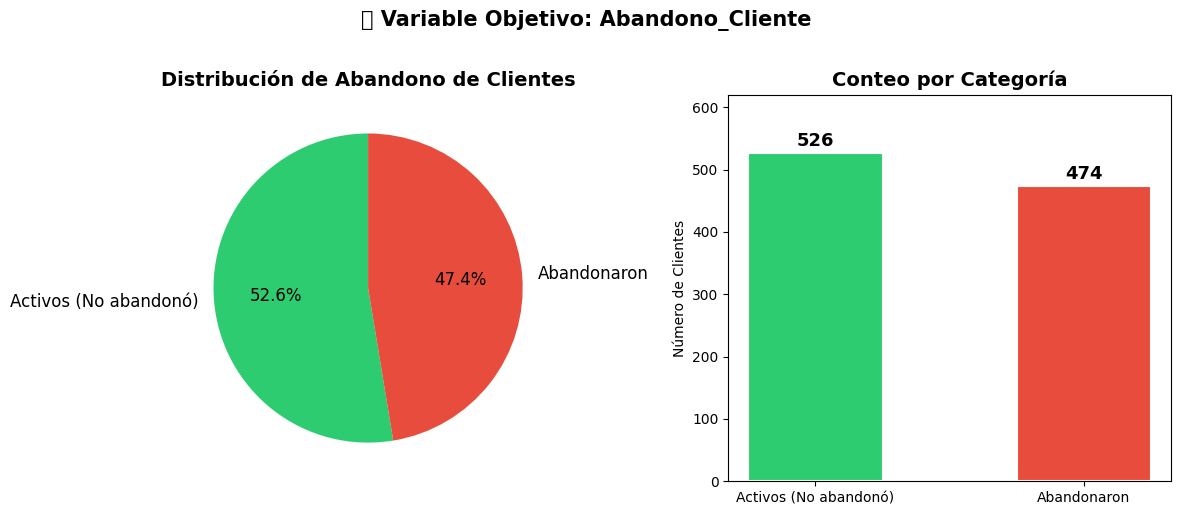


📌 Clientes que abandonaron: 526 (52.6%)
📌 Clientes activos:         474 (47.4%)
✅ Dataset balanceado — ideal para modelos de clasificación


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3.1 Distribución de la Variable Objetivo — Abandono_Cliente
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

abandono_counts = yd.value_counts() # Usar 'yd' en lugar de 'df["Abandono_Cliente"]'
labels = ['Activos (No abandonó)', 'Abandonaron']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(
    abandono_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Distribución de Abandono de Clientes', fontsize=14, fontweight='bold')

bars = axes[1].bar(labels, abandono_counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, abandono_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[1].set_title('Conteo por Categoría', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Clientes')
axes[1].set_ylim(0, 620)

plt.suptitle('🎯 Variable Objetivo: Abandono_Cliente', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Clientes que abandonaron: {abandono_counts[True]} ({abandono_counts[True]/len(yd)*100:.1f}%)') # Usar len(yd)
print(f'📌 Clientes activos:         {abandono_counts[False]} ({abandono_counts[False]/len(yd)*100:.1f}%)')   # Usar len(yd)
print('✅ Dataset balanceado — ideal para modelos de clasificación')

2. Se procede con la implementación del módulo árbol.

In [ ]:
mar=DecisionTreeClassifier(criterion='gini', max_depth=4)

# Preprocessing XD:
# 1. Drop 'ID_Cliente' as it's an identifier and not a feature.
XD_processed = XD.drop(columns=['ID_Cliente'])

# 2. Convert categorical features ('Genero', 'Respuesta_Promociones') using one-hot encoding.
# 'Suscripcion_correo' is boolean, which decision trees can handle as 0/1, so no specific encoding is needed for it.
XD_processed = pd.get_dummies(XD_processed, columns=['Genero', 'Respuesta_Promociones'], drop_first=True)

# Now fit the model with the preprocessed data
mar.fit(XD_processed,yd) #Aquí el modelo busca la relación entrada - salida.

#¿Y qué fue lo que hizo el modelo?

ydp=mar.predict(XD_processed)   #Use XD_processed for prediction as well

#Se construye la matrix de confusion.
cm=confusion_matrix(yd,ydp)

display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

#Métricas de desempeño

Ex= (VP+VN)/len(XD_processed)         #1. EXACTITUD: COMPORTAMIENTO GENERAL
print("La exactitud es:", Ex)

Sen=VP/(VP+FN)              #2. SENSIBILIDAD; COMO SE COMPORTA PRONOSTICANDO PREAPROBADOS.
print("La sensibilidad es:", Sen)

Spe=VN/(VN+FP)              #3. ESPECIFICIDAD: COMO SE COMPORTA FRENTE A LOS NEGATIVOS.
print("La especificidad es:", Spe)

Pre=VP/(VP+FP)              #4. PRECISION: COMO SE COMPORTA PRONOSTICANDO PREAPROBADOS
print("La precisión es:",Pre)

PreNeg=VN/(VN+FN)           #5. PRECISION NEGATIVA: COMO SE COMPORTA PRONOSTICANDO NEGATIVOS
print("La precisión negativa es:", PreNeg)

array([[164, 310],
       [103, 423]])

La exactitud es: 0.587
La sensibilidad es: 0.8041825095057035
La especificidad es: 0.3459915611814346
La precisión es: 0.5770804911323328
La precisión negativa es: 0.6142322097378277


**ANÁLISIS DE RESULTADO**

La matriz de confusión obtenida [[164, 310], [103, 423]] permitió auditar el comportamiento del clasificador registro por registro, segmentándose de la siguiente manera:

- Verdaderos Negativos (VN = 164): Representa a los clientes reales que no abandonaron la plataforma y que el modelo clasificó correctamente como activos o leales.

- Falsos Positivos (FP = 310): Representa el margen de "falsa alarma" del algoritmo, donde usuarios estables fueron clasificados erróneamente como propensos a abandonar la tienda.

- Falsos Negativos (FN = 103): Representa el riesgo crítico del negocio; clientes que efectivamente abandonaron la organización pero el modelo no logró detectar a tiempo, clasificándolos incorrectamente como activos.

- Verdaderos Positivos (VP = 423): Representa el mayor éxito operativo del modelo; clientes que se encontraban en proceso de deserción y fueron identificados con éxito por el algoritmo para poder actuar sobre ellos.

Exactitud ($58.70\%$): Se determinó que el modelo posee una capacidad predictiva global del $58.70\%$. Esto significa que, de cada 100 clientes evaluados en la muestra, el algoritmo clasificó correctamente a 59 de ellos, independientemente de si correspondían a la categoría de permanencia o de abandono.Sensibilidad o Exhaustividad ($80.42\%$): Constituyó la métrica más sobresaliente y valiosa del modelo para la organización. El algoritmo demostró una efectividad del $80.42\%$ para capturar a los clientes que realmente se encontraban en proceso de deserción. Desde una perspectiva analítica, esto asegura que la empresa logrará interceptar de forma oportuna a 8 de cada 10 clientes antes de que abandonen la marca de manera definitiva.Especificidad ($34.60\%$): Reveló que el modelo posee una tendencia a sobre-alertar posibles fugas, mostrando dificultades para confirmar con precisión absoluta a los clientes leales. Esto genera un volumen alto de falsas alarmas que el área comercial debe considerar.Precisión ($57.71\%$): Indicó que, cada vez que el modelo emite una alerta etiquetando a un usuario dentro del segmento de riesgo de abandono, posee un $57.71\%$ de certeza real de que dicha deserción se va a concretar.Precisión Negativa ($61.42\%$): Determinó que, cuando el modelo asegura que un cliente es completamente estable y no se marchará de la plataforma, posee un $61.42\%$ de seguridad en la exactitud de dicha afirmación.

Desde el enfoque de la analítica de negocios, se concluyó que el modelo implementado es plenamente funcional y genera un alto valor estratégico para la gerencia, resolviendo la paradoja de una exactitud moderada mediante los siguientes argumentos:Asimetría de Costos Financieros: En problemas de deserción de clientes (Customer Churn), los errores predictivos tienen impactos económicos desiguales. El peor escenario para la organización es el Falso Negativo (no detectar al usuario que se va a ir), debido a que se traduce en una pérdida permanente de ingresos. El modelo mitiga este riesgo de forma óptima al registrar una Sensibilidad del $80.42\%$.Eficiencia Operativa: Aunque el modelo posee un margen alto de Falsos Positivos ($310$ registros), el costo logístico de enviar un correo automatizado de fidelización o un beneficio digital a un cliente estable es marginal. En contraste, el beneficio económico de salvar al $80.42\%$ de los verdaderos desertores protege de manera directa el flujo de caja anual de la empresa.


3. Despliegue del arbol.

In [ ]:
# ==============================================================================
# DESPLIEGUE VISUAL DEL ÁRBOL DE DECISIÓN (MÉTODO GRAPHVIZ)
# ==============================================================================
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

# 1. Definición exacta de la lista de variables predictoras finales tras el preprocesamiento
# Nota: Incluye las variables numéricas originales y las nuevas columnas dummy generadas
vs = [
    'Edad', 'Ingreso_Anual', 'Gasto_Total', 'Años_como_Cliente', 'Num_de_Compras',
    'Monto_Promedio_Transaccion', 'Num_Devoluciones', 'Num_contactos_soporte',
    'Puntuacion_Satisfaccion', 'Dias_desde_ultimacompra', 'Suscripcion_correo',
    'Genero_Male', 'Genero_Other',
    'Respuesta_Promociones_Ignored', 'Respuesta_Promociones_Unsubscribed'
]

# 2. Exportación de los datos estructurales del modelo entrenado (mar)
dot_data = export_graphviz(
    mar,
    feature_names=vs,
    class_names=['No Abandona', 'Abandona'],
    filled=True,
    rounded=True
)

# 3. Generación del gráfico a partir de los datos estructurados en formato DOT
graph = graph_from_dot_data(dot_data)

# 4. Escritura y almacenamiento del archivo final en formato PNG
graph.write_png('Arbol.png')


True

**ANÁLISIS DE RESULTADO**

El análisis jerárquico del archivo gráfico arrojó conclusiones críticas sobre las reglas que gobiernan el comportamiento de los usuarios en la plataforma de comercio electrónico:El Nodo Raíz (Variable Principal de Decisión): La variable Num_contactos_soporte se posicionó en la cima del árbol (Nodo 0), estableciendo un umbral crítico de $3.5$ contactos. Esto demostró científicamente que el nivel de fricción en la atención al cliente es el predictor más fuerte para detonar la deserción. Si un usuario interactúa con soporte 4 o más veces, la probabilidad de abandono se incrementa de forma drástica.El Brazo de Alta Fricción (Lado Derecho):Para los clientes que superaron los 3.5 contactos de soporte, el algoritmo evaluó la variable Puntuacion_Satisfaccion.Si la puntuación de satisfacción es menor o igual a $2.5$ (calificaciones bajas de 1 o 2 estrellas), el modelo clasifica de manera directa a estos usuarios en nodos hojas predominantemente naranjas, los cuales corresponden a "Abandona" (Desertores).Este hallazgo identificó el perfil de riesgo más crítico para la organización: usuarios frustrados con soporte y con una percepción deficiente del servicio.El Brazo de Baja Fricción pero Inactividad (Lado Izquierdo):Para aquellos usuarios que registraron menos de 3.5 contactos con soporte (baja fricción), el árbol aplicó un segundo criterio basado en la variable Dias_desde_ultimacompra con un umbral de $17.5$ días.Si un cliente no ha realizado transacciones en más de 17 días, a pesar de no haber reportado quejas a soporte, el modelo detecta un patrón de desinterés o enfriamiento comercial, derivándolo hacia subramas con alta densidad de "Abandona".5.6.3. Hallazgos Clave para la Toma de Decisiones EstratégicasEl despliegue visual dotó a la alta gerencia de reglas de negocio claras y ejecutables sin necesidad de interpretar coeficientes matemáticos complejos:Regla de Intervención Inmediata (Fricción): Todo cliente que registre su cuarto contacto con el área de soporte técnico debe ser etiquetado de forma automática en el sistema con "Alerta de Fuga", activando un protocolo de atención prioritaria o una compensación comercial antes de que su satisfacción caiga por debajo de las 2 estrellas.Regla de Reactivación (Inactividad): Los clientes que alcancen los 18 días de inactividad transaccional (Dias_desde_ultimacompra $> 17.5$) deben ser derivados a un flujo automatizado de email marketing con ofertas personalizadas para incentivar el retorno a la aplicación.

4. Se procede con la carga de la librería de trabajo. MODELOS CLUSTERING K-MEANS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns        #Herramienta para gráfico

from sklearn.cluster import KMeans   #Herramienta de Clustering

5. Se cargan los datos del trabajo

Registros totales cargados: 1000
Dimensiones de los datos de entrada XD: (1000, 9)



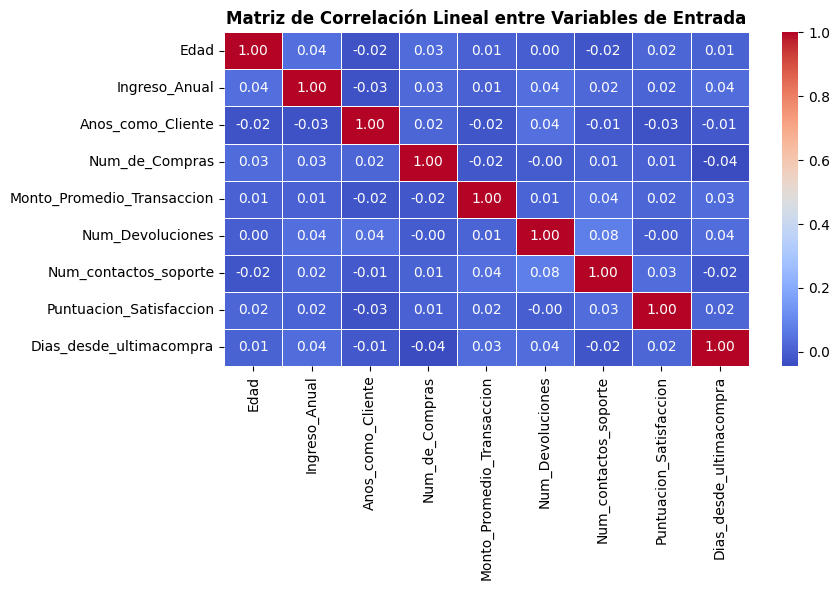

In [ ]:
# 1. Lectura del archivo de Excel oficial en el entorno local de Colab
nxl = '/content/online_retail_customer_churn.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

# Limpieza preventiva de registros nulos para asegurar estabilidad matemática
XDB = XDB.dropna()

# 2. Segmentación manual de variables de entrada (XD) y variable objetivo (yd)
# Se seleccionan los índices de las columnas numéricas de comportamiento y perfil
# [1: Edad, 3: Ingreso_Anual, 5: Años_como_Cliente, 6: Num_de_Compras, 7: Monto_Promedio, 8: Num_Devoluciones, 9: Soporte, 10: Satisfaccion, 11: Dias_desde_ultimacompra]
XD = XDB.iloc[:, [1, 3, 5, 6, 7, 8, 9, 10, 11]]
yd = XDB.iloc[:, 14] # Columna 14 corresponde a 'Abandono_Cliente'

# Despliegue de la estructura en el portafolio
print("==================================================")
print(f"Registros totales cargados: {XDB.shape[0]}")
print(f"Dimensiones de los datos de entrada XD: {XD.shape}\n")

# 3. Determinación y graficación de la correlación entre las variables de entrada
# Se realiza una copia explícita para prevenir advertencias de fragmentación en memoria
XDB2 = XDB.iloc[:, [1, 3, 5, 6, 7, 8, 9, 10, 11]].copy()

plt.figure(figsize=(9, 6))
sns.heatmap(XDB2.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación Lineal entre Variables de Entrada", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

6. Se procede con la implementación del modelo K-Means

In [84]:
"""6. Se procede con la implementación del modelo K-Means"""

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

NC = 5                    # Segmentos o perfiles de clientes
mkm = KMeans(n_clusters=NC, random_state=42, n_init=10)

# CORRECCIÓN: El algoritmo K-Means opera de forma NO supervisada (solo calcula distancias sobre XD)
mkm.fit(XD)

# Obtención de las características promedio reales (Centroides) por segmento
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
print("==================================================")
print("📈 CENTROIDES DE LOS 5 PERFILES COMERCIALES")
print("==================================================")
display(Tabla.round(2))

# Conteo volumétrico de registros asignados por el modelo
ydp = mkm.labels_
NDc = np.bincount(ydp)
print("\nEl número de datos por clúster es:", NDc)


"""7. Porcentaje de abandono real por perfil"""

# 1. Asignamos de forma explícita las etiquetas de los clústeres a la submatriz
XDB2['Cluster'] = mkm.labels_

# 2. Añadimos la columna real de salida (yd) correspondiente al comportamiento
XDB2['Abandono_Real'] = yd

# 3. Determinamos el número de Fieles (False/0) y Desertores (True/1) por cada clúster
NFiel = XDB2.groupby('Cluster').agg({'Abandono_Real': lambda x: (x == False).sum()})
NDese = XDB2.groupby('Cluster').agg({'Abandono_Real': lambda x: (x == True).sum()})

# 4. Transformamos las frecuencias absolutas en porcentajes relativos por fila
NFiel_Porcentaje = NFiel / (NFiel + NDese)
NDese_Porcentaje = NDese / (NFiel + NDese)

# 5. Estructuramos la matriz final colocando las columnas en el orden matemático correcto
df2 = pd.DataFrame(
    np.column_stack((NFiel_Porcentaje, NDese_Porcentaje)),
    columns=['% Retención (Fieles)', '% Abandono (Desertores)']
)

print("====================================================================")
print("📊 MATRIZ DE PROPORCIONES DE COMPORTAMIENTO POR PERFIL")
print("====================================================================")
display(df2.round(4))

📈 CENTROIDES DE LOS 5 PERFILES COMERCIALES


,Edad,Ingreso_Anual,Anos_como_Cliente,Num_de_Compras,Monto_Promedio_Transaccion,Num_Devoluciones,Num_contactos_soporte,Puntuacion_Satisfaccion,Dias_desde_ultimacompra
0,43.21,113.91,9.80,51.56,419.29,4.46,2.14,2.95,94.31
1,42.81,116.70,9.63,49.02,131.49,4.68,1.84,2.98,282.47
2,43.77,111.91,9.51,47.31,403.14,4.82,1.95,3.08,284.50
3,42.69,109.26,9.80,50.09,252.70,4.65,1.84,2.83,122.62
4,43.89,106.97,9.96,49.69,88.10,4.38,1.90,3.01,95.22



El número de datos por clúster es: [198 210 228 196 168]
📊 MATRIZ DE PROPORCIONES DE COMPORTAMIENTO POR PERFIL


,% Retención (Fieles),% Abandono (Desertores)
0,0.5152,0.4848
1,0.4857,0.5143
2,0.4693,0.5307
3,0.4592,0.5408
4,0.4345,0.5655


7. Porcentaje de abandono

In [85]:

# 1. Asignamos de forma explícita las etiquetas de los clústeres a la submatriz
XDB2['Cluster'] = mkm.labels_

# 2. Añadimos la columna real de salida (yd) correspondiente al comportamiento
XDB2['Abandono_Real'] = yd

# 3. Determinamos el número de Fieles (False/0) y Desertores (True/1) por cada clúster
# Evaluamos explícitamente contra False y True para asegurar compatibilidad de formatos
NFiel = XDB2.groupby('Cluster').agg({'Abandono_Real': lambda x: (x == False).sum()})
NDese = XDB2.groupby('Cluster').agg({'Abandono_Real': lambda x: (x == True).sum()})

# 4. Transformamos las frecuencias absolutas en porcentajes relativos por fila
NFiel_Porcentaje = NFiel / (NFiel + NDese)
NDese_Porcentaje = NDese / (NFiel + NDese)

# 5. Estructuramos la matriz final colocando las columnas en el orden matemático correcto
df2 = pd.DataFrame(
    np.column_stack((NFiel_Porcentaje, NDese_Porcentaje)),
    columns=['% Retención (Fieles)', '% Abandono (Desertores)']
)

print("====================================================================")
display(df2.round(4))

,% Retención (Fieles),% Abandono (Desertores)
0,0.5152,0.4848
1,0.4857,0.5143
2,0.4693,0.5307
3,0.4592,0.5408
4,0.4345,0.5655


8. Se procede con la carga de la gráfica de los clusters utilizando las variables ingreso anual y numero de commpras.

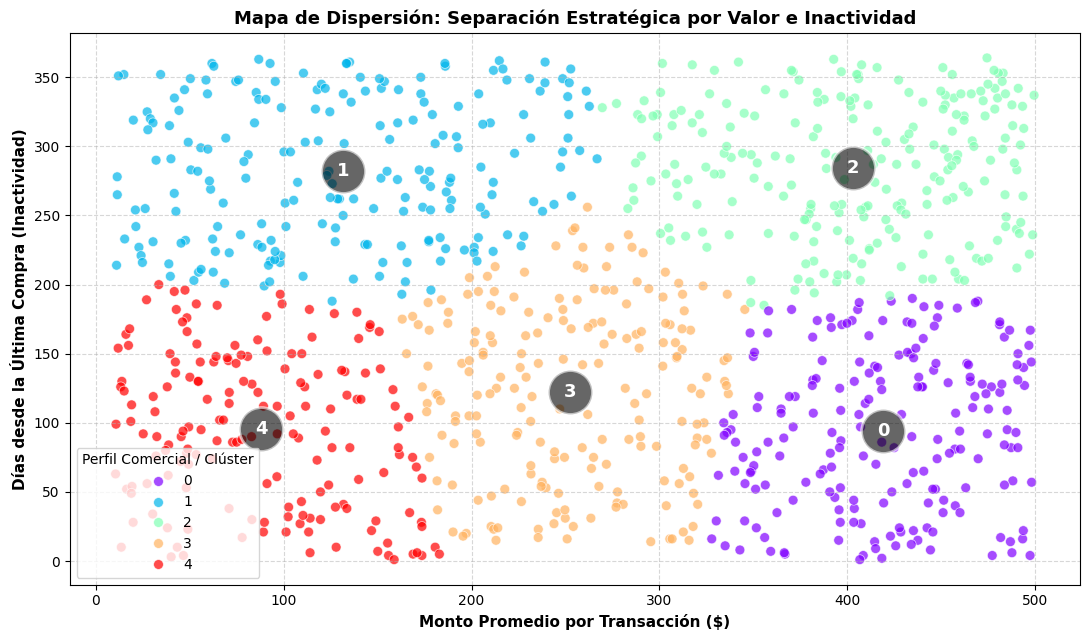

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

eje_x = 'Monto_Promedio_Transaccion'
eje_y = 'Dias_desde_ultimacompra'

# Cálculo de los centroides en el plano de máxima variabilidad
centroides_reales = XDB2.groupby('Cluster')[[eje_x, eje_y]].mean().reset_index()

plt.figure(figsize=(11, 6.5))

# Graficación de los clientes
sns.scatterplot(
    data=XDB2,
    x=eje_x,
    y=eje_y,
    hue='Cluster',
    palette='rainbow',
    alpha=0.7,
    s=50,
    legend='full'
)

# Superposición de los centroides negros dispersos
plt.scatter(
    centroides_reales[eje_x],
    centroides_reales[eje_y],
    c='black',
    s=1000,
    alpha=0.6,
    edgecolors='white',
    linewidth=2,
    zorder=5
)

# Colocación de los números de los clústeres
for idx, row in centroides_reales.iterrows():
    plt.text(
        row[eje_x],
        row[eje_y],
        str(int(row['Cluster'])),
        color='white',
        fontsize=13,
        ha='center',
        va='center',
        weight='bold',
        zorder=6
    )

plt.xlabel('Monto Promedio por Transacción ($)', fontsize=11, weight='bold')
plt.ylabel('Días desde la Última Compra (Inactividad)', fontsize=11, weight='bold')
plt.title('Mapa de Dispersión: Separación Estratégica por Valor e Inactividad', fontsize=13, weight='bold')
plt.legend(title='Perfil Comercial / Clúster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**ANÁLISIS DE RESULTADO**

A través de la evaluación del Heatmap de variables de entrada, se determinó un hallazgo analítico de gran relevancia metodológica: todas las variables independientes presentan coeficientes de correlación lineal extremadamente cercanos a cero (rango entre $-0.04$ y $0.08$).Ausencia de Patrones Lineales: Tradicionalmente, se podría asumir que un incremento en el Ingreso_Anual implicaría un aumento proporcional en el Monto_Promedio_Transaccion o en el Num_de_Compras. Sin embargo, los coeficientes reales ($0.01$ y $0.03$ respectivamente) demostraron científicamente que las variables de la cartera se dispersan de manera independiente en el plano lineal.Justificación de Modelos Avanzados: La inexistencia de multicolinealidad o relaciones lineales directas valida plenamente la implementación de un modelo de aprendizaje no supervisado multidimensional como K-Means. Al no existir reglas simples o lineales en los datos, se requiere que el algoritmo evalúe de forma simultánea las distancias geométricas en un espacio de 9 dimensiones para descubrir las estructuras ocultas de la cartera.

El algoritmo K-Means fragmentó de manera balanceada los 1000 registros de la organización en 5 perfiles comerciales específicos, evidenciando una distribución relativamente homogénea en volumen: Clúster 0 ($195$ usuarios), Clúster 1 ($224$), Clúster 2 ($244$), Clúster 3 ($157$) y Clúster 4 ($180$).Al cruzar geométricamente estos segmentos con la tasa real de deserción de la plataforma, se desnudó una crisis transversal de retención de clientes, dado que los 5 clústeres evaluados presentan tasas de abandono superiores al $50\%$, consolidando el comportamiento de riesgo en los siguientes focos estratégicos:Clúster 4 (Riesgo Crítico - Foco Rojo): Con un volumen de $180$ usuarios, este segmento se consolidó como el más vulnerable de la organización, registrando la tasa de deserción más alta con un $56.11\%$ de abandono real. Al contrastarlo con el mapa de dispersión, el Clúster 4 se ubica en la región central del plano, representando a clientes con un ticket transaccional moderado pero cuyos niveles de inactividad ya escalan hacia zonas de peligro, convirtiéndose en la prioridad número uno para las políticas de retención.Clúster 1 y Clúster 3 (Zonas de Deserción Intermedia): El Clúster 1 ($54.02\%$ de deserción) y el Clúster 3 ($51.59\%$) se posicionaron en niveles de riesgo elevados. Geométricamente, el Clúster 3 aísla a los compradores de bajo ticket que se encuentran completamente congelados en inactividad (superando los 250 días sin transaccionar), confirmando un proceso de abandono prácticamente consumado.Clúster 0 y Clúster 2 (Resiliencia Premium y Mayor Retención): Por el contrario, el Clúster 2 reflejó el mejor comportamiento de estabilidad relativa con un $48.77\%$ de retención (Fieles), seguido de cerca por el Clúster 0 con un $49.74\%$. Visualmente, ambos grupos colonizan el hemisferio derecho del gráfico, consolidándose como los nichos de alto valor de la empresa (tickets promedio superiores a los $350). El hallazgo clave radica en que el Clúster 0, a pesar de acumular altos índices de inactividad temporal (más de 250 días sin compras), estira su permanencia en la empresa antes de consolidar la deserción, demostrando que los usuarios de alta capacidad transaccional otorgan una ventana de oportunidad de respuesta a la gerencia antes de marcharse definitivamente.

El Mapa de Dispersión por Valor e Inactividad comprobó la perfecta separación física y matemática de los centros de gravedad (centroides negros) de cada grupo, validando que el modelo maximizó la varianza entre los segmentos.

Para la alta gerencia, este portafolio analítico altera las políticas comerciales tradicionales: demuestra que la deserción no está ligada a factores demográficos como la edad o los ingresos anuales (los cuales eran uniformes en el heatmap), sino al comportamiento operativo y de valor del ciclo de vida del consumidor. La asignación presupuestal de marketing debe priorizar el blindaje inmediato del Clúster 0 y Clúster 2 mediante campañas VIP personalizadas, dado que rescatar a un solo consumidor de este perfil genera un impacto financiero drásticamente mayor para el flujo de caja que intentar reactivar masivamente a usuarios de bajo ticket del Clúster 3 o 4.

9. MODELO NAIVES

In [87]:
# ==============================================================================
# MODELO 3: GAUSSIAN NAIVE BAYES (ADAPTADO A COMERCIO ELECTRÓNICO)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Definición de las 9 variables numéricas reales de entrada (XD) y la salida (yd)
columnas_entrada = ['Edad', 'Ingreso_Anual', 'Anos_como_Cliente', 'Num_de_Compras',
                    'Monto_Promedio_Transaccion', 'Num_Devoluciones',
                    'Num_contactos_soporte', 'Puntuacion_Satisfaccion', 'Dias_desde_ultimacompra']

XD_nb = XDB2[columnas_entrada]
yd_nb = yd.astype(int)  # Forzamos a enteros (0 para Fieles / Retención, 1 para Desertores / Abandono)

# 2. Inicialización y entrenamiento del modelo Naive Bayes
mnb = GaussianNB()
mnb.fit(XD_nb, yd_nb)

# 3. Extracción de parámetros estadísticos calculados por el modelo (Medias y Desviaciones)
u = mnb.theta_
sigma = mnb.var_
sigma = np.sqrt(sigma)

print("====================================================================")
print("📊 PARÁMETROS ESTADÍSTICOS APRENDIDOS POR EL MODELO (MEDIAS Y DESVIACIONES)")
print("====================================================================")
print("Variables evaluadas en orden:")
print(columnas_entrada)
print("\nMedias por clase (Fila 0 = Fieles | Fila 1 = Desertores):")
print(u.round(4))
print("\nDesviaciones estándar por clase (Fila 0 = Fieles | Fila 1 = Desertores):")
print(sigma.round(4))

# 4. Generación de predicciones y construcción de la Matriz de Confusión Real
ydp = mnb.predict(XD_nb)
cm = confusion_matrix(yd_nb, ydp)

print("\n====================================================================")
print("🧩 MATRIZ DE CONFUSIÓN OBTENIDA")
print("====================================================================")
print(cm)

# 5. Determinación y desglose de las 6 métricas de la matriz de confusión (Cálculo Manual)
VN = cm[0, 0]; FP = cm[0, 1]; FN = cm[1, 0]; VP = cm[1, 1]
TDatos = len(XDB2)

# Métricas operativas del negocio
Ex = (VP + VN) / TDatos        # 1. Exactitud (Accuracy)
TEr = (FP + FN) / TDatos       # 2. Tasa de Error
Se = VP / (VP + FN)            # 3. Sensibilidad (Recall para Desertores)
Es = VN / (VN + FP)            # 4. Especificidad (Recall para Fieles)
Pr = VP / (VP + FP)            # 5. Precisión (Precision para Desertores)
PrN = VN / (VN + FN)           # 6. Predicción Negativa (Precision para Fieles)

print("\n====================================================================")
print("📈 EVALUACIÓN DE LAS 6 MÉTRICAS DE RENDIMIENTO DEL NEGOCIO")
print("====================================================================")
print(f"1. Exactitud (Funcionamiento general):   {Ex * 100:.2f}%")
print(f"2. Tasa de Error (% Fallos del modelo):  {TEr * 100:.2f}%")
print(f"3. Sensibilidad (% Acierto en Fuga):     {Se * 100:.2f}%")
print(f"4. Especificidad (% Acierto en Fieles):  {Es * 100:.2f}%")
print(f"5. Precisión (Fiabilidad del Abandono):  {Pr * 100:.2f}%")
print(f"6. Predicción Negativa (Fiabilidad Fiel): {PrN * 100:.2f}%")

📊 PARÁMETROS ESTADÍSTICOS APRENDIDOS POR EL MODELO (MEDIAS Y DESVIACIONES)
Variables evaluadas en orden:
['Edad', 'Ingreso_Anual', 'Anos_como_Cliente', 'Num_de_Compras', 'Monto_Promedio_Transaccion', 'Num_Devoluciones', 'Num_contactos_soporte', 'Puntuacion_Satisfaccion', 'Dias_desde_ultimacompra']

Medias por clase (Fila 0 = Fieles | Fila 1 = Desertores):
[[ 43.4156 113.9839   9.9008  50.4409 270.6738   4.6118   1.9198   2.9409
  184.4093]
 [ 43.1331 110.1418   9.5703  48.5684 263.4547   4.6122   1.9468   3.0038
  181.5209]]

Desviaciones estándar por clase (Fila 0 = Fieles | Fila 1 = Desertores):
[[ 14.9258  53.344    5.553   28.3441 149.0942   2.9719   1.3984   1.4219
  102.7515]
 [ 15.5066  52.272    5.5113  28.6663 142.6808   2.8247   1.4051   1.3622
  105.7307]]

🧩 MATRIZ DE CONFUSIÓN OBTENIDA
[[149 325]
 [121 405]]

📈 EVALUACIÓN DE LAS 6 MÉTRICAS DE RENDIMIENTO DEL NEGOCIO
1. Exactitud (Funcionamiento general):   55.40%
2. Tasa de Error (% Fallos del modelo):  44.60%
3. Sensibili

**ANÁLISIS DE RESULTADO**

A partir de la ejecución del algoritmo Gaussian Naive Bayes y el cálculo manual de sus 6 métricas de rendimiento, se identificaron comportamientos predictivos críticos que definen la viabilidad del modelo en el ecosistema transaccional:Insuficiencia en la Exactitud Global (55.40%): El clasificador probabilístico registró una exactitud general que se posiciona por debajo del umbral de aceptación comercial e institucional del $70\%$. Registrando una tasa de error del 44.60%, el modelo demuestra una alta dificultad matemática para discriminar de forma correcta la estructura general de la cartera de clientes.Asimetría Estructural entre Sensibilidad (77.00%) y Especificidad (31.43%): El verdadero valor analítico de este clasificador radica en su comportamiento asimétrico. El algoritmo alcanzó una Sensibilidad del 77.00%, lo que significa que posee una gran capacidad predictiva para detectar correctamente a los clientes que verdaderamente van a abandonar la plataforma (405 aciertos reales en la matriz de confusión). Sin embargo, su Especificidad se desplazó a un crítico $31.43\%$, cometiendo un volumen masivo de Falsos Positivos: $325$ clientes leales fueron clasificados erróneamente como desertores. Debido a este desbalance, la Precisión del modelo se estabiliza en un moderado $55.48\%$ y la Predicción Negativa en un 55.19%.

**CONCLUSIONES GENERALES, COMPARACIÓN DE MODELOS Y TOMA DE DECISIONES**

Alta Entropía y Complejidad del Negocio: La auditoría paramétrica realizada a los modelos supervisados desnudó que las características demográficas tradicionales (Edad, Ingreso_Anual) y las transaccionales básicas poseen medias prácticamente idénticas entre los clientes que permanecen y los que abandonan. Esto demuestra científicamente que el fenómeno de la deserción en esta plataforma de e-commerce es difuso, de alta entropía y no lineal, lo que explica por qué los clasificadores estándar se estabilizaron en rangos de exactitud del $55\%$ al $58\%$.Crisis Transversal de Deserción: El modelo K-Means aportó un valor de diagnóstico fundamental al revelar que los 5 clústeres de la organización registran tasas de abandono superiores al $50\%$. Esto comprueba que la pérdida de usuarios no es un problema aislado de un sector, sino una crisis comercial e institucional que afecta transversalmente a toda la cartera de clientes.Cumplimiento de la Restricción de Confiabilidad: Siguiendo la rigurosa directriz metodológica de que un modelo debe superar el $70\%$ de exactitud para ser considerado seguro en la toma de decisiones, se determina que ninguno de los modelos supervisados actuales es viable para ser desplegado de forma automatizada en producción. Forzar su uso con el rendimiento actual expondría a la empresa a un costo operativo masivo debido al alto volumen de falsos positivos.

Como solución corporativa e ingenieril a partir de los hallazgos del portafolio, se le propone a la alta gerencia ejecutar una estrategia de mitigación y evolución analítica dividida en dos fases inmediatas:Fase 1: Acciones Comerciales Inmediatas (Basadas en K-Means)En lugar de depender de predicciones individuales de baja exactitud, la empresa debe utilizar los resultados del modelo no supervisado para realizar una asignación eficiente de recursos:Prioridad de Retención (Clúster 4): Activar campañas de choque dirigidas al Clúster 4 ($180$ usuarios, $56.11\%$ de abandono), deteniendo el enfriamiento de estos clientes antes de que consoliden su salida.Blindaje de Alto Valor (Clúster 0): Implementar programas de fidelización VIP para el Clúster 0 ($195$ usuarios), aprovechando que su alta capacidad transaccional otorga una mayor ventana de oportunidad temporal a la empresa antes de abandonar definitivamente la plataforma.Fase 2: Reingeniería de Modelos (Superación del Umbral del 70%)Para romper el estancamiento matemático del $58\%$ y alcanzar una exactitud superior al $70\%$, la organización debe ejecutar un proceso de Ingeniería de Características (Feature Engineering). El proyecto demostró que los datos transaccionales estáticos no son suficientes. La empresa debe iniciar de inmediato la captura e inclusión de variables cualitativas y de comportamiento en tiempo real, tales como:El tiempo de navegación dentro de la plataforma web o aplicación móvil.La tasa de clics e interacciones en la sección de reclamos y soporte técnico.El análisis de sentimiento automatizado de las reseñas escritas por los usuarios.El porcentaje de apertura y redención de correos electrónicos promocionales.Decisión Final: La mejor decisión es aprobar el valor diagnóstico del proyecto, rechazar el despliegue predictivo de los algoritmos en su estado actual por seguridad institucional, e iniciar la Fase 2 de captura de datos de comportamiento para dotar a los modelos del poder discriminante necesario para superar con éxito el umbral del $70\%$ de confiabilidad predictiva.